# Plant Disease Detection
DenseNet121 fine-tuned on the PlantVillage dataset (15 classes).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from keras.applications import DenseNet121
from keras.applications.densenet import preprocess_input
from keras.utils import load_img, img_to_array
from sklearn.metrics import confusion_matrix

print('TF version:', tf.__version__)

2026-05-16 11:21:15.804154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778930476.037594      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778930476.109087      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778930476.658853      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778930476.658900      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778930476.658903      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0


In [2]:
print(os.listdir('../input/datasets/emmarex/plantdisease/PlantVillage/'))

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = 15

DATA_DIR = '../input/datasets/emmarex/plantdisease/PlantVillage/'

DISEASE_CLASSES = [
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

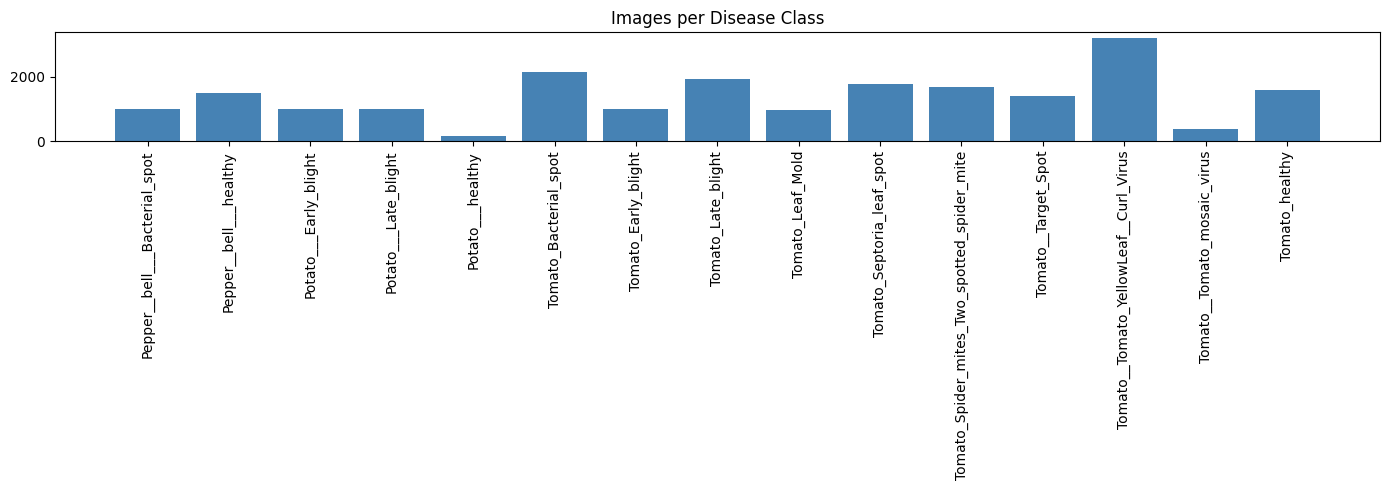

Total images: 20639


In [4]:
# ── Data exploration ─────────────────────────────────────────────────────────
class_counts = {
    cls: len(os.listdir(os.path.join(DATA_DIR, cls)))
    for cls in DISEASE_CLASSES
    if os.path.exists(os.path.join(DATA_DIR, cls))
}

plt.figure(figsize=(14, 5))
plt.bar(range(len(class_counts)), list(class_counts.values()), color='steelblue')
plt.xticks(range(len(class_counts)), list(class_counts.keys()), rotation=90)
plt.title('Images per Disease Class')
plt.tight_layout()
plt.show()
print('Total images:', sum(class_counts.values()))

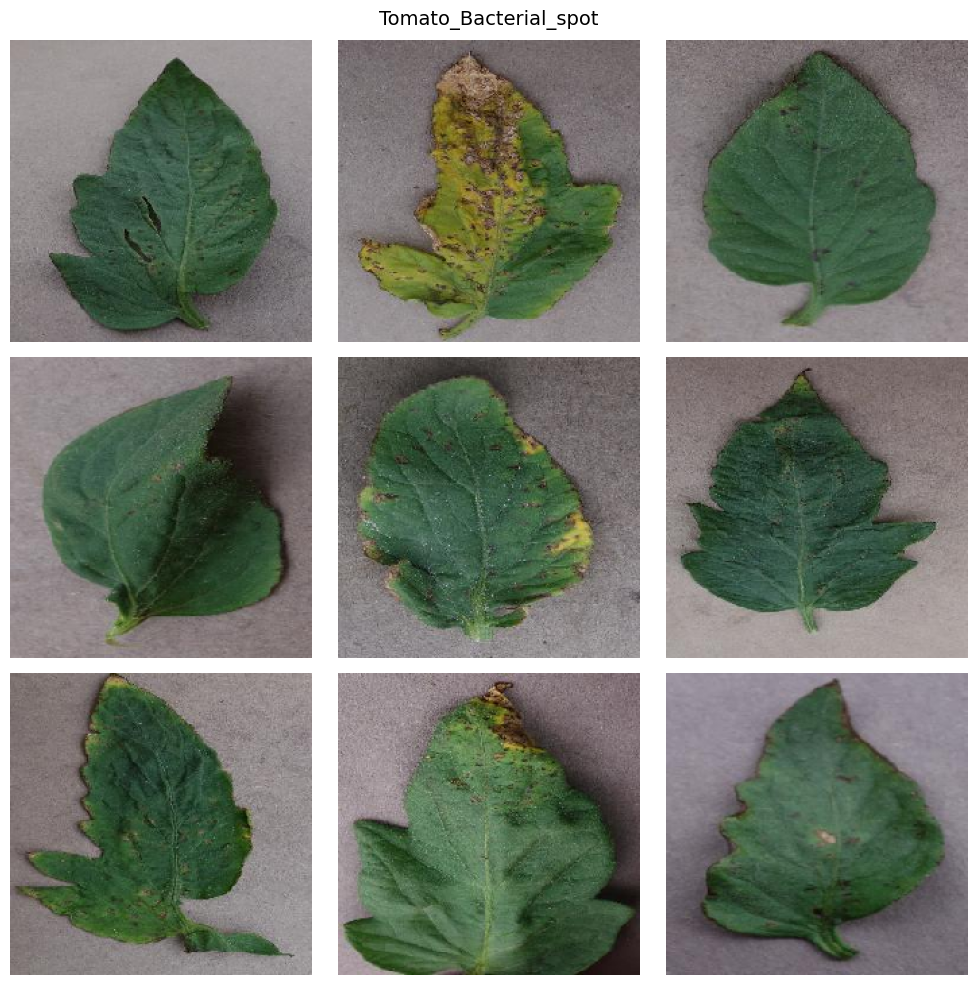

In [5]:
# Sample images — load_img uses PIL so always RGB, no BGR issue
sample_class = 'Tomato_Bacterial_spot'
sample_files = os.listdir(os.path.join(DATA_DIR, sample_class))[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, fname in zip(axes.flatten(), sample_files):
    img = load_img(os.path.join(DATA_DIR, sample_class, fname), target_size=(224, 224))
    ax.imshow(img)
    ax.axis('off')
plt.suptitle(sample_class, fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ── Data generators ──────────────────────────────────────────────────────────
# flow_from_directory loads batches on demand — no OOM at 224x224
# preprocess_input matches DenseNet121 ImageNet pretraining (mean subtraction)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    classes=DISEASE_CLASSES
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False,
    classes=DISEASE_CLASSES
)

print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Training samples  : 16516
Validation samples: 4122


In [7]:
# ── Model ────────────────────────────────────────────────────────────────────
def build_model():
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )
    base.trainable = False

    inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, output), base

model, base_model = build_model()
model.summary()

I0000 00:00:1778930529.169562      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778930529.175511      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,308,879 (27.88 MB)

 Trainable params: 268,815 (1.03 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [8]:
# ── Phase 1: frozen base, train top layers ───────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint('model.h5', save_best_only=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
]

hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)
print('Phase 1 complete')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778930547.540695     147 service.cc:152] XLA service 0x7cd29c001c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778930547.540738     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778930547.540743     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778930551.086396     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/517 ━━━━━━━━━━━━━━━━━━━━ 4:17:08 30s/step - accuracy: 0.0625 - loss: 4.6465

I0000 00:00:1778930564.035904     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

517/517 ━━━━━━━━━━━━━━━━━━━━ 209s 404ms/step - accuracy: 0.8687 - loss: 0.3860 - val_accuracy: 0.9403 - val_loss: 0.1797 - learning_rate: 0.0010
Epoch 9/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8663 - loss: 0.3952
Epoch 9: val_accuracy did not improve from 0.94032
517/517 ━━━━━━━━━━━━━━━━━━━━ 211s 408ms/step - accuracy: 0.8663 - loss: 0.3952 - val_accuracy: 0.9284 - val_loss: 0.2080 - learning_rate: 0.0010
Epoch 10/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8802 - loss: 0.3452
Epoch 10: val_accuracy did not improve from 0.94032
517/517 ━━━━━━━━━━━━━━━━━━━━ 208s 403ms/step - accuracy: 0.8801 - loss: 0.3453 - val_accuracy: 0.9379 - val_loss: 0.1749 - learning_rate: 0.0010
Epoch 11/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8756 - loss: 0.3634
Epoch 11: val_accuracy improved from 0.94032 to 0.94347, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 211s 408ms/step - accuracy: 0.8756 - loss: 0.3634 - val_accuracy: 0.9435 - val_loss: 0.1716 - learning_rate: 0.0010
Epoch 12/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8795 - loss: 0.3501
Epoch 12: val_accuracy improved from 0.94347 to 0.94784, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 213s 411ms/step - accuracy: 0.8795 - loss: 0.3501 - val_accuracy: 0.9478 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 13/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8797 - loss: 0.3441
Epoch 13: val_accuracy did not improve from 0.94784
517/517 ━━━━━━━━━━━━━━━━━━━━ 204s 394ms/step - accuracy: 0.8797 - loss: 0.3441 - val_accuracy: 0.9427 - val_loss: 0.1723 - learning_rate: 0.0010
Epoch 14/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8860 - loss: 0.3352
Epoch 14: val_accuracy improved from 0.94784 to 0.95197, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 204s 394ms/step - accuracy: 0.8860 - loss: 0.3352 - val_accuracy: 0.9520 - val_loss: 0.1517 - learning_rate: 0.0010
Epoch 15/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8858 - loss: 0.3317
Epoch 15: val_accuracy did not improve from 0.95197
517/517 ━━━━━━━━━━━━━━━━━━━━ 212s 410ms/step - accuracy: 0.8858 - loss: 0.3317 - val_accuracy: 0.9427 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 16/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8860 - loss: 0.3328
Epoch 16: val_accuracy did not improve from 0.95197
517/517 ━━━━━━━━━━━━━━━━━━━━ 218s 421ms/step - accuracy: 0.8860 - loss: 0.3328 - val_accuracy: 0.9452 - val_loss: 0.1722 - learning_rate: 0.0010
Epoch 17/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8906 - loss: 0.3183
Epoch 17: val_accuracy did not improve from 0.95197

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
517/517 ━━━━━━━━━━━━━━━━━━━━ 220s 426ms/step - accuracy: 0.8906 

517/517 ━━━━━━━━━━━━━━━━━━━━ 213s 412ms/step - accuracy: 0.8934 - loss: 0.3133 - val_accuracy: 0.9522 - val_loss: 0.1500 - learning_rate: 5.0000e-04
Epoch 19/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8952 - loss: 0.3018
Epoch 19: val_accuracy did not improve from 0.95221
517/517 ━━━━━━━━━━━━━━━━━━━━ 210s 406ms/step - accuracy: 0.8952 - loss: 0.3018 - val_accuracy: 0.9515 - val_loss: 0.1452 - learning_rate: 5.0000e-04
Epoch 20/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8904 - loss: 0.3198
Epoch 20: val_accuracy did not improve from 0.95221
517/517 ━━━━━━━━━━━━━━━━━━━━ 212s 410ms/step - accuracy: 0.8904 - loss: 0.3198 - val_accuracy: 0.9517 - val_loss: 0.1454 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.
Phase 1 complete


In [9]:
# ── Phase 2: unfreeze top 50 DenseNet layers, fine-tune ─────────────────────
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)
print('Phase 2 complete')

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8862 - loss: 0.3264
Epoch 1: val_accuracy did not improve from 0.95221
517/517 ━━━━━━━━━━━━━━━━━━━━ 294s 501ms/step - accuracy: 0.8862 - loss: 0.3264 - val_accuracy: 0.9491 - val_loss: 0.1563 - learning_rate: 1.0000e-05
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8946 - loss: 0.3103
Epoch 2: val_accuracy did not improve from 0.95221
517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 416ms/step - accuracy: 0.8946 - loss: 0.3103 - val_accuracy: 0.9517 - val_loss: 0.1487 - learning_rate: 1.0000e-05
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8979 - loss: 0.2951
Epoch 3: val_accuracy improved from 0.95221 to 0.95366, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 218s 422ms/step - accuracy: 0.8979 - loss: 0.2952 - val_accuracy: 0.9537 - val_loss: 0.1449 - learning_rate: 1.0000e-05
Epoch 4/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9028 - loss: 0.2910
Epoch 4: val_accuracy improved from 0.95366 to 0.95415, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 212s 410ms/step - accuracy: 0.9028 - loss: 0.2910 - val_accuracy: 0.9541 - val_loss: 0.1368 - learning_rate: 1.0000e-05
Epoch 5/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9013 - loss: 0.2865
Epoch 5: val_accuracy improved from 0.95415 to 0.95439, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 212s 411ms/step - accuracy: 0.9013 - loss: 0.2865 - val_accuracy: 0.9544 - val_loss: 0.1349 - learning_rate: 1.0000e-05
Epoch 6/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9027 - loss: 0.2810
Epoch 6: val_accuracy did not improve from 0.95439
517/517 ━━━━━━━━━━━━━━━━━━━━ 209s 404ms/step - accuracy: 0.9027 - loss: 0.2810 - val_accuracy: 0.9541 - val_loss: 0.1383 - learning_rate: 1.0000e-05
Epoch 7/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9082 - loss: 0.2665
Epoch 7: val_accuracy improved from 0.95439 to 0.95609, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 206s 398ms/step - accuracy: 0.9082 - loss: 0.2665 - val_accuracy: 0.9561 - val_loss: 0.1319 - learning_rate: 1.0000e-05
Epoch 8/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9101 - loss: 0.2642
Epoch 8: val_accuracy improved from 0.95609 to 0.95657, saving model to model.h5


...

517/517 ━━━━━━━━━━━━━━━━━━━━ 203s 393ms/step - accuracy: 0.9286 - loss: 0.2028 - val_accuracy: 0.9629 - val_loss: 0.1068 - learning_rate: 1.0000e-05
Epoch 25/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9304 - loss: 0.2095
Epoch 25: val_accuracy did not improve from 0.96288
517/517 ━━━━━━━━━━━━━━━━━━━━ 203s 392ms/step - accuracy: 0.9304 - loss: 0.2095 - val_accuracy: 0.9629 - val_loss: 0.1065 - learning_rate: 1.0000e-05
Epoch 26/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9322 - loss: 0.2042
Epoch 26: val_accuracy improved from 0.96288 to 0.96385, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 202s 391ms/step - accuracy: 0.9322 - loss: 0.2043 - val_accuracy: 0.9639 - val_loss: 0.1003 - learning_rate: 1.0000e-05
Epoch 27/30
263/517 ━━━━━━━━━━━━━━━━━━━━ 1:34 374ms/step - accuracy: 0.9314 - loss: 0.2085
Epoch 27: val_accuracy improved from 0.96385 to 0.96507, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 206s 397ms/step - accuracy: 0.9313 - loss: 0.2050 - val_accuracy: 0.9651 - val_loss: 0.1004 - learning_rate: 1.0000e-05
Epoch 28/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9298 - loss: 0.2049
Epoch 28: val_accuracy improved from 0.96507 to 0.96555, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 204s 395ms/step - accuracy: 0.9298 - loss: 0.2049 - val_accuracy: 0.9656 - val_loss: 0.0989 - learning_rate: 1.0000e-05
Epoch 29/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9345 - loss: 0.1913
Epoch 29: val_accuracy did not improve from 0.96555
517/517 ━━━━━━━━━━━━━━━━━━━━ 205s 396ms/step - accuracy: 0.9345 - loss: 0.1913 - val_accuracy: 0.9651 - val_loss: 0.1005 - learning_rate: 1.0000e-05
Epoch 30/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9388 - loss: 0.1832
Epoch 30: val_accuracy improved from 0.96555 to 0.96604, saving model to model.h5


517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 417ms/step - accuracy: 0.9388 - loss: 0.1832 - val_accuracy: 0.9660 - val_loss: 0.0960 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 30.
Phase 2 complete


129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9722 - loss: 0.0805
Final Loss: 0.0960  |  Final Accuracy: 0.9660
129/129 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step


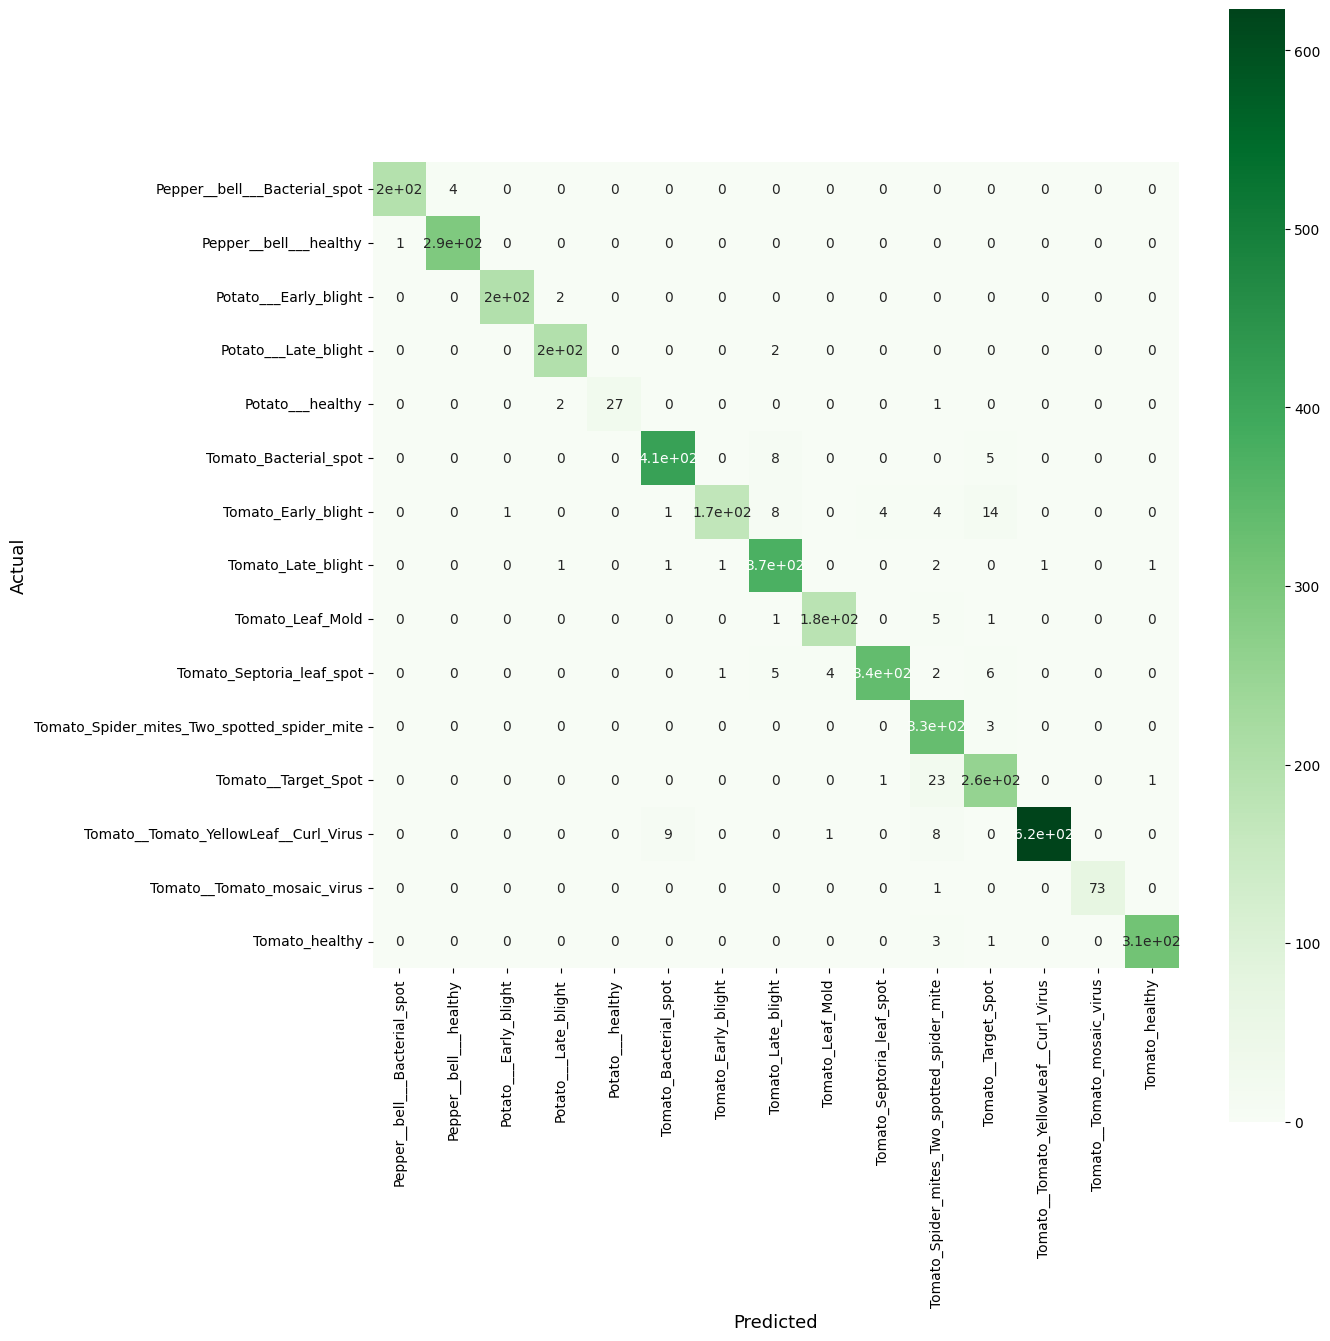

In [10]:
# ── Evaluation ───────────────────────────────────────────────────────────────
final_loss, final_accuracy = model.evaluate(val_gen)
print(f'Final Loss: {final_loss:.4f}  |  Final Accuracy: {final_accuracy:.4f}')

Y_pred = np.argmax(model.predict(val_gen), axis=1)
Y_true = val_gen.classes

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(14, 14))
ax = sns.heatmap(cm, cmap='Greens', annot=True, square=True,
                 xticklabels=DISEASE_CLASSES, yticklabels=DISEASE_CLASSES)
ax.set_ylabel('Actual', fontsize=13)
ax.set_xlabel('Predicted', fontsize=13)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

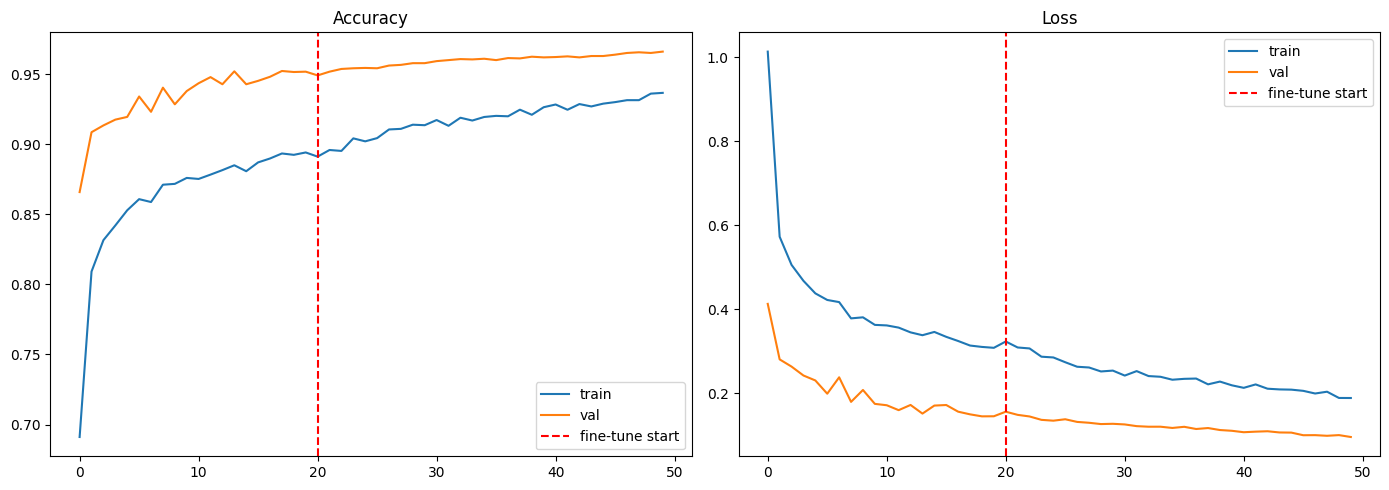

In [11]:
# ── Training history ─────────────────────────────────────────────────────────
acc      = hist1.history['accuracy']     + hist2.history['accuracy']
val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
loss     = hist1.history['loss']         + hist2.history['loss']
val_loss = hist1.history['val_loss']     + hist2.history['val_loss']
split    = len(hist1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, train, val, title in [
    (ax1, acc,  val_acc,  'Accuracy'),
    (ax2, loss, val_loss, 'Loss')
]:
    ax.plot(train, label='train')
    ax.plot(val,   label='val')
    ax.axvline(split, color='red', linestyle='--', label='fine-tune start')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

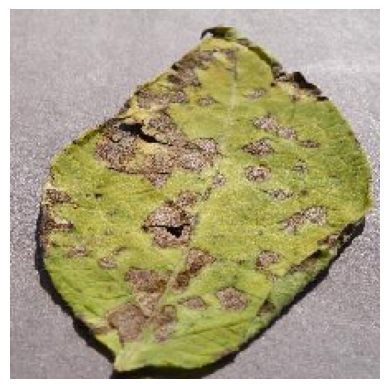

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction : Potato___Early_blight
Confidence : 100.0%


In [13]:
# ── Single image inference test ──────────────────────────────────────────────
test_path = '../input/datasets/emmarex/plantdisease/PlantVillage/Potato___Early_blight/042135e2-e126-4900-9212-d42d900b8125___RS_Early.B 8791.JPG'

img = load_img(test_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
plt.imshow(img)
plt.axis('off')
plt.show()

x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
ind   = np.argmax(preds[0])
print(f'Prediction : {DISEASE_CLASSES[ind]}')
print(f'Confidence : {preds[0][ind]*100:.1f}%')